# LISA Traffic Light Detection with YOLOv8
## Complete Workflow: From Dataset Exploration to Model Export

This notebook walks you through the entire process of building a traffic light detector using the LISA dataset and YOLOv8:
1. **Explore** the raw LISA dataset structure and annotations
2. **Convert** Supervisly JSON annotations to YOLO format
3. **Prepare** the dataset with train/val/test splits
4. **Train** a YOLOv8 object detection model
5. **Evaluate** the model on validation and test sets
6. **Infer** predictions on sample images
7. **Export** the model to ONNX format for deployment

The dataset is pre-split into `Dataset/train/` and `Dataset/test/`. We'll create a validation split from train.

In [1]:
pip install numpy matplotlib pillow ultralytics


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 1. SETUP AND IMPORTS
import os
import sys
import json
import shutil
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Project paths
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "Dataset"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RUNS_DIR = PROJECT_ROOT / "runs"

print(f"Project Root: {PROJECT_ROOT}")
print(f"Dataset Dir: {DATASET_DIR}")
print(f"Processed Data Dir: {DATA_PROCESSED_DIR}")

# # Create output directories if they don't exist
# DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
# MODELS_DIR.mkdir(parents=True, exist_ok=True)
# RUNS_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Directories ready")

Project Root: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project
Dataset Dir: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/Dataset
Processed Data Dir: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/processed
✓ Directories ready


## Step 1: Explore the LISA Dataset Structure

Let's first understand what we're working with:
- Dataset is organized in `Dataset/train/` and `Dataset/test/`
- Each split has `img/` (images) and `ann/` (Supervisly JSON annotations)
- Annotations contain bounding boxes with class labels

In [3]:
# 2. EXPLORE DATASET STRUCTURE
print("DATASET STRUCTURE")

# Check meta.json
with open(DATASET_DIR / "meta.json") as f:
    meta = json.load(f)

print(f"\nClasses in Dataset ({len(meta['classes'])} total):")
CLASS_NAMES = []
for idx, cls in enumerate(meta['classes']):
    CLASS_NAMES.append(cls['title'])
    print(f"  {idx}: {cls['title']}")

CLASS_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}
print(f"\n✓ Total classes: {len(CLASS_NAMES)}")

# Explore train split
train_img_dir = DATASET_DIR / "train" / "img"
train_ann_dir = DATASET_DIR / "train" / "ann"
train_images = sorted([f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
train_anns = sorted([f for f in os.listdir(train_ann_dir) if f.endswith('.json')])

print(f"\nTrain Split:")
print(f"  Images: {len(train_images)}")
print(f"  Annotations: {len(train_anns)}")
print(f"  Sample images: {train_images[:3]}")

# Explore test split
test_img_dir = DATASET_DIR / "test" / "img"
test_ann_dir = DATASET_DIR / "test" / "ann"
test_images = sorted([f for f in os.listdir(test_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
test_anns = sorted([f for f in os.listdir(test_ann_dir) if f.endswith('.json')])

print(f"\nTest Split:")
print(f"  Images: {len(test_images)}")
print(f"  Annotations: {len(test_anns)}")
print(f"  Sample images: {test_images[:3]}")

print(f"\nTotal images across all splits: {len(train_images) + len(test_images)}")

DATASET STRUCTURE

Classes in Dataset (14 total):
  0: go
  1: go forward
  2: go forward traffic light
  3: go left
  4: go left traffic light
  5: go traffic light
  6: stop
  7: stop left
  8: stop left traffic light
  9: stop traffic light
  10: warning
  11: warning left
  12: warning left traffic light
  13: warning traffic light

✓ Total classes: 14

Train Split:
  Images: 20535
  Annotations: 20535
  Sample images: ['dayClip1--00000.jpg', 'dayClip1--00001.jpg', 'dayClip1--00002.jpg']

Test Split:
  Images: 22481
  Annotations: 22481
  Sample images: ['daySequence1--00000.jpg', 'daySequence1--00001.jpg', 'daySequence1--00002.jpg']

Total images across all splits: 43016


## Step 2: Understand the Annotation Format

Let's examine a few annotation files to understand the JSON structure.

In [4]:
# 3. EXAMINE ANNOTATION FORMAT
print("="*60)
print("ANNOTATION FORMAT EXAMPLE")
print("="*60)

# Load one annotation to understand structure
sample_ann_file = train_ann_dir / train_anns[0]
with open(sample_ann_file) as f:
    sample_ann = json.load(f)

print(f"\nAnnotation file: {train_anns[0]}")
print(f"Image dimensions: {sample_ann['size']['width']} x {sample_ann['size']['height']}")
print(f"Number of objects: {len(sample_ann.get('objects', []))}")

print("\nFirst object structure:")
if sample_ann.get('objects'):
    obj = sample_ann['objects'][0]
    print(f"  classTitle: {obj['classTitle']}")
    print(f"  geometryType: {obj['geometryType']}")
    print(f"  points.exterior: {obj['points']['exterior']}")  # [[x1,y1], [x2,y2]]
    print(f"  points format: [[top-left], [bottom-right]]")

# Show all classes in this annotation
print("\nAll classes in this image:")
for obj in sample_ann.get('objects', []):
    print(f"  - {obj['classTitle']}")

ANNOTATION FORMAT EXAMPLE

Annotation file: dayClip1--00000.jpg.json
Image dimensions: 1280 x 960
Number of objects: 4

First object structure:
  classTitle: go traffic light
  geometryType: rectangle
  points.exterior: [[698, 333], [710, 358]]
  points format: [[top-left], [bottom-right]]

All classes in this image:
  - go traffic light
  - go traffic light
  - go
  - go


## Step 3: Visualize an Annotation

Let's load an image and its annotations, then visualize the bounding boxes.

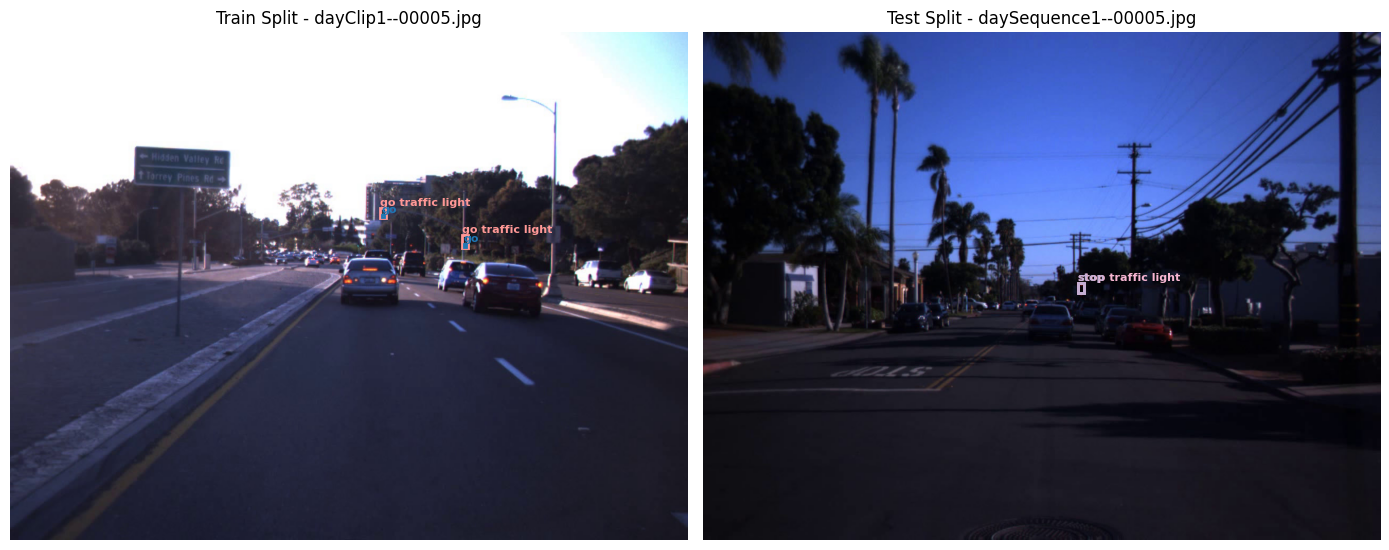

✓ Visualized sample annotations from train and test splits


In [5]:
# 4. VISUALIZE ANNOTATION
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (split_name, img_dir, ann_dir, anns) in enumerate([
    ("Train", train_img_dir, train_ann_dir, train_anns),
    ("Test", test_img_dir, test_ann_dir, test_anns)
]):
    # Load image and annotation
    ann_file = ann_dir / anns[5]  # Pick 5th image for variety
    img_name = str(ann_file.name).replace('.json', '')
    img_path = img_dir / img_name
    
    img = Image.open(img_path)
    with open(ann_file) as f:
        ann = json.load(f)
    
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(f"{split_name} Split - {img_name}")
    ax.axis('off')
    
    # Draw bounding boxes
    colors = plt.cm.get_cmap('tab20')(np.linspace(0, 1, len(CLASS_NAMES)))
    color_map = {name: colors[i] for i, name in enumerate(CLASS_NAMES)}
    
    for obj in ann.get('objects', []):
        pts = obj['points']['exterior']
        x1, y1 = pts[0]
        x2, y2 = pts[1]
        x_min = min(x1, x2)
        y_min = min(y1, y2)
        width = abs(x2 - x1)
        height = abs(y2 - y1)
        
        class_title = obj['classTitle']
        color = color_map[class_title]
        
        rect = Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x_min, y_min - 5, class_title, fontsize=8, color=color, weight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualized sample annotations from train and test splits")

## Step 4: Convert LISA Annotations to YOLO Format

YOLO expects:
- For each image: a corresponding `.txt` file with one line per object
- Format: `class_id x_center y_center width height`
- All coordinates normalized to [0, 1]

We'll convert the Supervisly JSON format to YOLO format.

In [6]:
# 5. CONVERT LISA ANNOTATIONS TO YOLO FORMAT
print("="*60)
print("CONVERTING ANNOTATIONS TO YOLO FORMAT")
print("="*60)

def convert_annotation_to_yolo(ann_data, class_map):
    """Convert Supervisly annotation to YOLO format"""
    img_h = ann_data["size"]["height"]
    img_w = ann_data["size"]["width"]
    
    yolo_lines = []
    for obj in ann_data.get("objects", []):
        class_title = obj.get("classTitle", "").strip()
        if not class_title or class_title not in class_map:
            continue
        
        pts = obj["points"]["exterior"]
        if len(pts) != 2:
            continue
        
        x1, y1 = pts[0]
        x2, y2 = pts[1]
        
        x_min = min(x1, x2)
        x_max = max(x1, x2)
        y_min = min(y1, y2)
        y_max = max(y1, y2)
        
        # Normalize to [0, 1]
        x_center = ((x_min + x_max) / 2.0) / img_w
        y_center = ((y_min + y_max) / 2.0) / img_h
        width = (x_max - x_min) / img_w
        height = (y_max - y_min) / img_h
        
        # Clamp to [0, 1]
        x_center = max(0, min(1, x_center))
        y_center = max(0, min(1, y_center))
        width = max(0, min(1, width))
        height = max(0, min(1, height))
        
        class_id = class_map[class_title]
        yolo_line = f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        yolo_lines.append(yolo_line)
    
    return yolo_lines

def process_split(split_name, img_dir, ann_dir, out_img_dir, out_lbl_dir, class_map, use_symlink=True):
    """Process one split (train/test) and convert to YOLO format"""
    print(f"\nProcessing {split_name} split...")
    
    ann_files = sorted([f for f in os.listdir(ann_dir) if f.endswith(".json")])
    processed = 0
    
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)
    
    for ann_file in ann_files:
        ann_path = os.path.join(ann_dir, ann_file)
        img_name = ann_file.replace(".json", "")  # e.g., "image.jpg"
        img_path = os.path.join(img_dir, img_name)
        
        if not os.path.exists(img_path):
            continue
        
        # Convert annotation
        with open(ann_path) as f:
            ann_data = json.load(f)
        yolo_lines = convert_annotation_to_yolo(ann_data, class_map)
        
        # Create symlink or copy for image
        out_img_path = os.path.join(out_img_dir, img_name)
        if not os.path.exists(out_img_path):
            if use_symlink:
                os.symlink(os.path.abspath(img_path), out_img_path)
            else:
                shutil.copy2(img_path, out_img_path)
        
        # Write YOLO label file
        lbl_name = img_name + ".txt"
        out_lbl_path = os.path.join(out_lbl_dir, lbl_name)
        with open(out_lbl_path, "w") as f:
            f.write("\n".join(yolo_lines))
            if yolo_lines:
                f.write("\n")
        
        processed += 1
    
    print(f"  ✓ Processed {processed} images from {split_name}")
    return processed

# Process train split
train_processed = process_split(
    "Train",
    img_dir=str(train_img_dir),
    ann_dir=str(train_ann_dir),
    out_img_dir=str(DATA_PROCESSED_DIR / "images" / "train"),
    out_lbl_dir=str(DATA_PROCESSED_DIR / "labels" / "train"),
    class_map=CLASS_MAP,
    use_symlink=True
)

# Process test split
test_processed = process_split(
    "Test",
    img_dir=str(test_img_dir),
    ann_dir=str(test_ann_dir),
    out_img_dir=str(DATA_PROCESSED_DIR / "images" / "test"),
    out_lbl_dir=str(DATA_PROCESSED_DIR / "labels" / "test"),
    class_map=CLASS_MAP,
    use_symlink=True
)

print(f"\n✓ Total: {train_processed + test_processed} images converted")

CONVERTING ANNOTATIONS TO YOLO FORMAT

Processing Train split...
  ✓ Processed 20535 images from Train

Processing Test split...
  ✓ Processed 22481 images from Test

✓ Total: 43016 images converted


## Step 5: Create Validation Split from Train

We'll sample 10% of training images to create a validation split for model tuning.

In [7]:
# 6. CREATE VALIDATION SPLIT (10% from train)
print("="*60)
print("CREATING VALIDATION SPLIT")
print("="*60)

train_img_dir = DATA_PROCESSED_DIR / "images" / "train"
train_lbl_dir = DATA_PROCESSED_DIR / "labels" / "train"
val_img_dir = DATA_PROCESSED_DIR / "images" / "val"
val_lbl_dir = DATA_PROCESSED_DIR / "labels" / "val"

os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_lbl_dir, exist_ok=True)

# Get all train images
train_images_list = sorted([f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
n_val = max(1, int(len(train_images_list) * 0.1))
val_images = set(random.sample(train_images_list, n_val))

print(f"\nTotal train images: {len(train_images_list)}")
print(f"Moving to val split: {len(val_images)} ({100*len(val_images)/len(train_images_list):.1f}%)")

# Move images and labels to val
for img_name in val_images:
    # Move image
    src_img = train_img_dir / img_name
    dst_img = val_img_dir / img_name
    if src_img.exists():
        # If symlink, recreate it in val; if file, move it
        if os.path.islink(src_img):
            target = os.readlink(src_img)
            if dst_img.exists() or dst_img.is_symlink():
                dst_img.unlink()
            os.symlink(target, dst_img)
            os.remove(src_img)
        else:
            shutil.move(str(src_img), str(dst_img))
    
    # Move label
    lbl_name = img_name + ".txt"
    src_lbl = train_lbl_dir / lbl_name
    dst_lbl = val_lbl_dir / lbl_name
    if src_lbl.exists():
        shutil.move(str(src_lbl), str(dst_lbl))

# Verify splits
train_count = len([f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
val_count = len([f for f in os.listdir(val_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
test_count = len([f for f in os.listdir(DATA_PROCESSED_DIR / "images" / "test") if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print(f"\nFinal split:")
print(f"  Train: {train_count} images")
print(f"  Val:   {val_count} images")
print(f"  Test:  {test_count} images")
print(f"  Total: {train_count + val_count + test_count} images")

CREATING VALIDATION SPLIT

Total train images: 20535
Moving to val split: 2053 (10.0%)

Final split:
  Train: 18482 images
  Val:   5601 images
  Test:  22481 images
  Total: 46564 images


## Step 6: Create YOLOv8 Configuration File (data.yaml)

YOLOv8 needs a YAML file pointing to the dataset location and class names.

In [8]:
# 7. CREATE DATA.YAML FOR YOLOV8
print("="*60)
print("CREATING YOLOv8 CONFIGURATION (data.yaml)")
print("="*60)

yaml_content = """path: data/processed
train: images/train
val: images/val
test: images/test

nc: {nc}
names:
{names_list}
""".format(
    nc=len(CLASS_NAMES),
    names_list="\n".join([f"  {idx}: {name}" for idx, name in enumerate(CLASS_NAMES)])
)

yaml_path = DATA_PROCESSED_DIR / "data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"\nCreated: {yaml_path}")
print(f"Classes: {len(CLASS_NAMES)}")
print("\nContent:")
print(yaml_content)

CREATING YOLOv8 CONFIGURATION (data.yaml)

Created: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/processed/data.yaml
Classes: 14

Content:
path: data/processed
train: images/train
val: images/val
test: images/test

nc: 14
names:
  0: go
  1: go forward
  2: go forward traffic light
  3: go left
  4: go left traffic light
  5: go traffic light
  6: stop
  7: stop left
  8: stop left traffic light
  9: stop traffic light
  10: warning
  11: warning left
  12: warning left traffic light
  13: warning traffic light



## Step 7: Filter the Dataset to Detectable Classes

The previous training runs failed (all losses stayed at 0) because the dataset mixes two kinds of objects:
- **Traffic light housings** (the lamp boxes) — ~6×13 px at imgsz=640 — small but detectable.
- **Individual bulbs** (`go`, `stop`, `warning`, etc.) — ~2×3 px at imgsz=640 — **smaller than YOLOv8's minimum detector stride**, so the model literally cannot learn them.

The bulb labels were poisoning training. The cell below rewrites every label file in `data/processed/labels/{train,val,test}/`, keeping only the 7 housing classes and renumbering them 0–6. It also updates `data.yaml` to declare 7 classes instead of 14.

Run this once, then re-run the training cell below.

In [9]:
# 7. FILTER DATASET TO 7 HOUSING CLASSES
# The bulb classes (go, stop, warning, etc.) are only 2-3 px wide at imgsz=640
# and YOLOv8 cannot learn objects smaller than its detector stride (~8 px).
# Earlier training runs collapsed (all losses = 0) because of this.
# We keep only the 7 "* traffic light" housing classes and renumber them 0-6.
print("="*60)
print("FILTERING DATASET TO 7 HOUSING CLASSES")
print("="*60)

KEEP_NAMES = [n for n in CLASS_NAMES if n.endswith("traffic light")]
OLD_TO_NEW = {CLASS_NAMES.index(n): new_id for new_id, n in enumerate(KEEP_NAMES)}

print(f"\nKeeping {len(KEEP_NAMES)} classes:")
for new_id, name in enumerate(KEEP_NAMES):
    print(f"  old id {CLASS_NAMES.index(name):2d}  ->  new id {new_id}:  {name}")

total = kept = empty_after = 0
for split in ["train", "val", "test"]:
    lbl_dir = DATA_PROCESSED_DIR / "labels" / split
    if not lbl_dir.exists():
        continue
    files = list(lbl_dir.glob("*.txt"))
    for f in files:
        new_lines = []
        for line in f.read_text().splitlines():
            parts = line.strip().split()
            if not parts:
                continue
            total += 1
            old_id = int(parts[0])
            if old_id in OLD_TO_NEW:
                new_lines.append(f"{OLD_TO_NEW[old_id]} " + " ".join(parts[1:]))
                kept += 1
        f.write_text(("\n".join(new_lines) + "\n") if new_lines else "")
        if not new_lines:
            empty_after += 1
    print(f"  {split}: rewrote {len(files)} label files")

print(f"\nKept {kept}/{total} annotations ({100*kept/total:.1f}%)")
print(f"Images with no housings (now empty .txt = background): {empty_after}")

# Rewrite data.yaml for 7 classes
yaml_content = (
    "path: data/processed\n"
    "train: images/train\n"
    "val: images/val\n"
    "test: images/test\n\n"
    f"nc: {len(KEEP_NAMES)}\n"
    "names:\n"
    + "\n".join(f"  {i}: {n}" for i, n in enumerate(KEEP_NAMES)) + "\n"
)
(DATA_PROCESSED_DIR / "data.yaml").write_text(yaml_content)
print(f"\n✓ data.yaml updated to {len(KEEP_NAMES)} classes:\n{yaml_content}")


FILTERING DATASET TO 7 HOUSING CLASSES

Keeping 7 classes:
  old id  2  ->  new id 0:  go forward traffic light
  old id  4  ->  new id 1:  go left traffic light
  old id  5  ->  new id 2:  go traffic light
  old id  8  ->  new id 3:  stop left traffic light
  old id  9  ->  new id 4:  stop traffic light
  old id 12  ->  new id 5:  warning left traffic light
  old id 13  ->  new id 6:  warning traffic light
  train: rewrote 36964 label files
  val: rewrote 5969 label files
  test: rewrote 44962 label files

Kept 109825/311223 annotations (35.3%)
Images with no housings (now empty .txt = background): 51402

✓ data.yaml updated to 7 classes:
path: data/processed
train: images/train
val: images/val
test: images/test

nc: 7
names:
  0: go forward traffic light
  1: go left traffic light
  2: go traffic light
  3: stop left traffic light
  4: stop traffic light
  5: warning left traffic light
  6: warning traffic light



## Step 8: Verify Prepared Dataset

Let's verify the dataset is correctly prepared by checking a few YOLO labels and visualizing them.

In [10]:
# 8. VERIFY PREPARED DATASET
print("="*60)
print("VERIFYING PREPARED DATASET")
print("="*60)

# Check a few YOLO label files
sample_lbl_files = sorted(os.listdir(DATA_PROCESSED_DIR / "labels" / "train"))[:3]

print("\nSample YOLO label files:")
for lbl_file in sample_lbl_files:
    lbl_path = DATA_PROCESSED_DIR / "labels" / "train" / lbl_file
    with open(lbl_path) as f:
        content = f.read()
    print(f"\n{lbl_file}:")
    if content.strip():
        for line in content.strip().split('\n'):
            parts = line.split()
            class_id = int(parts[0])
            class_name = CLASS_NAMES[class_id]
            print(f"  {class_name}: {line}")
    else:
        print("  (no objects)")

print("\n✓ Dataset verification complete")

VERIFYING PREPARED DATASET

Sample YOLO label files:

dayClip1--00000.jpg.txt:
  go forward traffic light: 2 0.550000 0.359896 0.009375 0.026042
  go forward traffic light: 2 0.665625 0.417708 0.009375 0.020833

dayClip1--00000.txt:
  (no objects)

dayClip1--00001.jpg.txt:
  go forward traffic light: 2 0.550000 0.361458 0.009375 0.020833
  go forward traffic light: 2 0.666406 0.416667 0.009375 0.020833

✓ Dataset verification complete


## Step 9: Install YOLOv8 and Dependencies

In [11]:
# 9. INSTALL YOLOV8
import subprocess
import sys

print("="*60)
print("INSTALLING YOLOV8 AND DEPENDENCIES")
print("="*60)

packages = ['ultralytics']

for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} installed")

print("\n✓ All dependencies ready")

INSTALLING YOLOV8 AND DEPENDENCIES
✓ ultralytics already installed

✓ All dependencies ready


## Step 10: Train the Two-Stage Model

Two independent training runs:

1. **Stage 1 — YOLOv8 (single class `traffic_light`):** finds housings, no class info.
2. **Stage 2 — MobileNetV3-Small:** takes the housing crop and reads the lit-bulb state (7 classes).

Sub-steps **10a → 10d** below build the per-stage datasets and run the trainings.
The inference plumbing that glues them together lives in Step 11.


In [24]:
# 10a. BUILD STAGE-1 DATASET (single-class 'traffic_light')
# Reuses the same images and the same boxes as data/processed/, but rewrites
# every class ID to 0. The result is YOLO-ready labels for a 1-class detector.
import shutil

STAGE1_DIR = PROJECT_ROOT / "data" / "stage1"
STAGE1_LBL = STAGE1_DIR / "labels"
SRC_LBL = DATA_PROCESSED_DIR / "labels"
SRC_IMG = DATA_PROCESSED_DIR / "images"

if STAGE1_LBL.exists():
    shutil.rmtree(STAGE1_LBL)

total_files = total_boxes = 0
for split in ("train", "val", "test"):
    src = SRC_LBL / split
    dst = STAGE1_LBL / split
    dst.mkdir(parents=True, exist_ok=True)
    if not src.exists():
        continue
    for f in src.glob("*.jpg.txt"):
        new_lines = []
        for line in f.read_text().splitlines():
            parts = line.strip().split()
            if not parts:
                continue
            # Rewrite the class id (first token) to 0; keep bbox unchanged.
            new_lines.append("0 " + " ".join(parts[1:]))
            total_boxes += 1
        # YOLO finds labels by replacing the image extension with ".txt", so we need
        # the label to be named "<image_stem>.txt", not "<image_stem>.jpg.txt".
        out_name = f.stem.rsplit(".", 1)[0] + ".txt"  # "img.jpg" -> "img.txt"
        (dst / out_name).write_text(("\n".join(new_lines) + "\n") if new_lines else "")
        total_files += 1

# YOLO resolves labels by swapping /images/ -> /labels/ in the image path. So
# we mirror the images under data/stage1/images/ via a symlink, then point the
# yaml's image roots at that local tree. This way labels land in our new dir.
# IMPORTANT: do NOT make data/stage1/images a directory symlink to
# data/processed/images. Ultralytics calls .resolve() on the YAML's image
# directory; a directory symlink would redirect label lookup to
# data/processed/labels/ where our stage-1 labels do not live. Instead, build
# data/stage1/images/<split>/ as REAL directories containing per-file symlinks.
# .resolve() then stays inside data/stage1/, so YOLO finds labels in
# data/stage1/labels/<split>/ as intended.
STAGE1_IMG = STAGE1_DIR / "images"
if STAGE1_IMG.is_symlink():
    STAGE1_IMG.unlink()
elif STAGE1_IMG.exists():
    shutil.rmtree(STAGE1_IMG)
STAGE1_IMG.mkdir(parents=True)
n_links = 0
for split in ("train", "val", "test"):
    src_dir = SRC_IMG / split
    dst_dir = STAGE1_IMG / split
    dst_dir.mkdir(parents=True, exist_ok=True)
    if not src_dir.exists():
        continue
    for img in src_dir.iterdir():
        if not (img.is_file() or img.is_symlink()):
            continue
        link = dst_dir / img.name
        # Point each link at the resolved source so YOLO can open the file
        # regardless of the symlink chain.
        link.symlink_to(img.resolve())
        n_links += 1
print(f"Created {n_links} per-file image symlinks under {STAGE1_IMG}")

# Clear any stale ultralytics label caches that may have been written under
# data/processed/labels/ from a previous (broken) run.
for c in (DATA_PROCESSED_DIR / "labels").glob("*.cache"):
    print(f"Removing stale cache: {c}")
    c.unlink()
for c in STAGE1_LBL.glob("*.cache"):
    print(f"Removing stage-1 cache: {c}")
    c.unlink()

stage1_yaml = STAGE1_DIR / "data.yaml"
stage1_yaml.write_text(
    "path: " + str(STAGE1_DIR) + "\n"
    "train: images/train\n"
    "val:   images/val\n"
    "test:  images/test\n\n"
    "nc: 1\n"
    "names:\n"
    "  0: traffic_light\n"
)

print(f"Rewrote {total_files} label files, {total_boxes} boxes -> class 0")
print(f"Stage-1 yaml: {stage1_yaml}")
print(stage1_yaml.read_text())


Created 46564 per-file image symlinks under /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/stage1/images
Rewrote 43016 label files, 109825 boxes -> class 0
Stage-1 yaml: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/stage1/data.yaml
path: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/stage1
train: images/train
val:   images/val
test:  images/test

nc: 1
names:
  0: traffic_light



In [25]:
# 10b. TRAIN STAGE-1 (single-class housing detector)
from ultralytics import YOLO
import traceback, torch, os

# Clear stale YOLO label caches so labels are re-parsed fresh.
for split in ("train", "val"):
    p = STAGE1_LBL / f"{split}.cache"
    if p.exists():
        p.unlink()

stage1_model = YOLO('yolov8n.pt')
try:
    stage1_results = stage1_model.train(
        data=str(stage1_yaml),
        epochs=30,                  # 1-class converges faster than 7-class
        imgsz=1280,
        batch=8,
        patience=8,
        device=0,                   # try GPU first
        amp=False,                  # AMP off — RTX 5090 + nightly-torch produced NaNs in box-loss path
        project=str(RUNS_DIR),
        name='stage1_localizer',
    )
except Exception as e:
    print("Stage-1 training failed on GPU:", e)
    traceback.print_exc()
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass
    # Fallback: retry on CPU with smaller imgsz/batch to avoid CUDA/kernel issues
    print("Retrying on CPU with reduced batch/imgsz...")
    stage1_results = stage1_model.train(
        data=str(stage1_yaml),
        epochs=30,
        imgsz=800,
        batch=2,
        patience=8,
        device='cpu',
        amp=False,
        project=str(RUNS_DIR),
        name='stage1_localizer_cpu_retry',
    )
print("\nStage 1 done. best.pt at:",
      RUNS_DIR / 'stage1_localizer' / 'weights' / 'best.pt')


New https://pypi.org/project/ultralytics/8.4.56 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.45 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32101MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/stage1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model

In [26]:
# 10c. BUILD STAGE-2 CROP DATASET (housing crops -> bulb-state label)
# For every box in data/processed/labels/<split>, crop the corresponding region
# from the image with a small padding, and save it under
# data/stage2/<split>/<class_name>/crop_NNN.jpg.  The class name comes from
# the 7-class label list in data/processed/data.yaml.
import yaml
from PIL import Image

STAGE2_DIR = PROJECT_ROOT / "data" / "stage2"
if STAGE2_DIR.exists():
    shutil.rmtree(STAGE2_DIR)

with open(DATA_PROCESSED_DIR / "data.yaml") as f:
    proc_yaml = yaml.safe_load(f)
STAGE2_CLASSES = [proc_yaml["names"][i] for i in range(proc_yaml["nc"])]
print("Stage-2 classes:", STAGE2_CLASSES)

PAD_RATIO = 0.15      # 15% padding around the housing
MIN_CROP_PX = 16      # skip housings whose smaller side is < this many px

counts = {c: 0 for c in STAGE2_CLASSES}
skipped = 0
for split in ("train", "val", "test"):
    img_dir = SRC_IMG / split
    lbl_dir = SRC_LBL / split
    if not img_dir.exists() or not lbl_dir.exists():
        continue
    for lbl_file in lbl_dir.glob("*.jpg.txt"):
        text = lbl_file.read_text().strip()
        if not text:
            continue
        # Filenames look like "dayClip10--00000.jpg.txt" -> strip the trailing ".txt"
        # and what's left is the image filename ("dayClip10--00000.jpg").
        img_path = img_dir / lbl_file.name[:-4]
        if not img_path.exists():
            continue
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception:
            continue
        W, H = img.size
        for line in text.splitlines():
            cls_id, cx, cy, bw, bh = line.split()
            cls_id = int(cls_id)
            cx, cy, bw, bh = float(cx), float(cy), float(bw), float(bh)
            cls_name = STAGE2_CLASSES[cls_id]
            # YOLO -> pixel xyxy
            x1 = (cx - bw / 2) * W
            y1 = (cy - bh / 2) * H
            x2 = (cx + bw / 2) * W
            y2 = (cy + bh / 2) * H
            pw, ph = (x2 - x1), (y2 - y1)
            if min(pw, ph) < MIN_CROP_PX:
                skipped += 1
                continue
            px = pw * PAD_RATIO
            py = ph * PAD_RATIO
            cx1 = max(0, int(x1 - px))
            cy1 = max(0, int(y1 - py))
            cx2 = min(W, int(x2 + px))
            cy2 = min(H, int(y2 + py))
            crop = img.crop((cx1, cy1, cx2, cy2))
            out_dir = STAGE2_DIR / split / cls_name.replace(" ", "_")
            out_dir.mkdir(parents=True, exist_ok=True)
            n = counts[cls_name]
            crop.save(out_dir / f"crop_{n:06d}.jpg", quality=92)
            counts[cls_name] += 1

print("\nCrops written per class (across all splits):")
for c, n in counts.items():
    print(f"  {c:30s}  {n}")
print(f"\nSkipped {skipped} boxes below {MIN_CROP_PX}px (too small even for stage 2).")


Stage-2 classes: ['go forward traffic light', 'go left traffic light', 'go traffic light', 'stop left traffic light', 'stop traffic light', 'warning left traffic light', 'warning traffic light']

Crops written per class (across all splits):
  go forward traffic light        522
  go left traffic light           1985
  go traffic light                26158
  stop left traffic light         10408
  stop traffic light              29993
  warning left traffic light      321
  warning traffic light           1739

Skipped 38699 boxes below 16px (too small even for stage 2).


In [27]:
# 10d. TRAIN STAGE-2 — MobileNetV3-Small, ImageNet pretrained, 7-way head
import collections
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

IMG_SIZE = 96
BATCH = 128
EPOCHS = 12

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(STAGE2_DIR / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(STAGE2_DIR / "val",   transform=eval_tf)
test_ds  = datasets.ImageFolder(STAGE2_DIR / "test",  transform=eval_tf)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")
print("Class -> index mapping:", train_ds.class_to_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=4, pin_memory=True)

# Class-balanced loss to handle imbalance (warning/go_left are rarer).
label_counts = collections.Counter(train_ds.targets)
weights = torch.tensor(
    [len(train_ds) / (len(label_counts) * label_counts[i]) for i in range(len(label_counts))],
    dtype=torch.float, device=DEVICE,
)
print("Class weights:", weights.cpu().numpy().round(2))

NUM_CLASSES = len(train_ds.classes)
net = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
# Replace the final Linear(1024 -> 1000) with a 7-way head.
in_feats = net.classifier[3].in_features
net.classifier[3] = nn.Linear(in_feats, NUM_CLASSES)
net = net.to(DEVICE)

opt = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
loss_fn = nn.CrossEntropyLoss(weight=weights)


@torch.no_grad()
def evaluate(loader):
    net.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = net(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


best_val = 0.0
STAGE2_OUT = MODELS_DIR / "stage2_mobilenet.pt"
STAGE2_OUT.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    net.train()
    running = 0.0
    seen = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        logits = net(x)
        loss = loss_fn(logits, y)
        loss.backward()
        opt.step()
        running += loss.item() * y.size(0)
        seen += y.size(0)
    sched.step()
    val_acc = evaluate(val_loader)
    print(f"epoch {epoch:02d}  train_loss={running/seen:.4f}  val_acc={val_acc*100:.2f}%")
    if val_acc > best_val:
        best_val = val_acc
        torch.save({
            "state_dict": net.state_dict(),
            "classes": train_ds.classes,
            "img_size": IMG_SIZE,
        }, STAGE2_OUT)

print(f"\nBest val acc: {best_val*100:.2f}%")
test_acc = evaluate(test_loader)
print(f"Test acc: {test_acc*100:.2f}%")
print(f"Saved stage-2 weights to: {STAGE2_OUT}")


Device: cuda
train=36712  val=4075  test=30339
Class -> index mapping: {'go_forward_traffic_light': 0, 'go_left_traffic_light': 1, 'go_traffic_light': 2, 'stop_left_traffic_light': 3, 'stop_traffic_light': 4, 'warning_left_traffic_light': 5, 'warning_traffic_light': 6}
Class weights: [      22.32        4.99        0.39        0.79        0.37       22.32        7.39]
epoch 01  train_loss=0.5305  val_acc=97.50%
epoch 02  train_loss=0.2387  val_acc=95.88%
epoch 03  train_loss=0.2235  val_acc=98.77%
epoch 04  train_loss=0.1968  val_acc=98.36%
epoch 05  train_loss=0.1990  val_acc=98.90%
epoch 06  train_loss=0.1904  val_acc=98.87%
epoch 07  train_loss=0.1882  val_acc=98.99%
epoch 08  train_loss=0.1843  val_acc=98.90%
epoch 09  train_loss=0.1936  val_acc=98.92%
epoch 10  train_loss=0.1852  val_acc=98.94%
epoch 11  train_loss=0.1841  val_acc=98.97%
epoch 12  train_loss=0.1835  val_acc=98.94%

Best val acc: 98.99%
Test acc: 92.91%
Saved stage-2 weights to: /home/auto_drive/Desktop/Traffic_Lig

## Step 11: Test the Pipeline on Sample Images

Visual sanity check. Loads both trained models, runs `two_stage_predict()` on a
handful of random test images, and saves an annotated `two_stage_demo.png`.

<!-- STEP-11-TEST -->


Stage 1 model: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/runs/stage1_localizer-5/weights/best.pt
Stage 2 classes: ['go_forward_traffic_light', 'go_left_traffic_light', 'go_traffic_light', 'stop_left_traffic_light', 'stop_traffic_light', 'warning_left_traffic_light', 'warning_traffic_light']


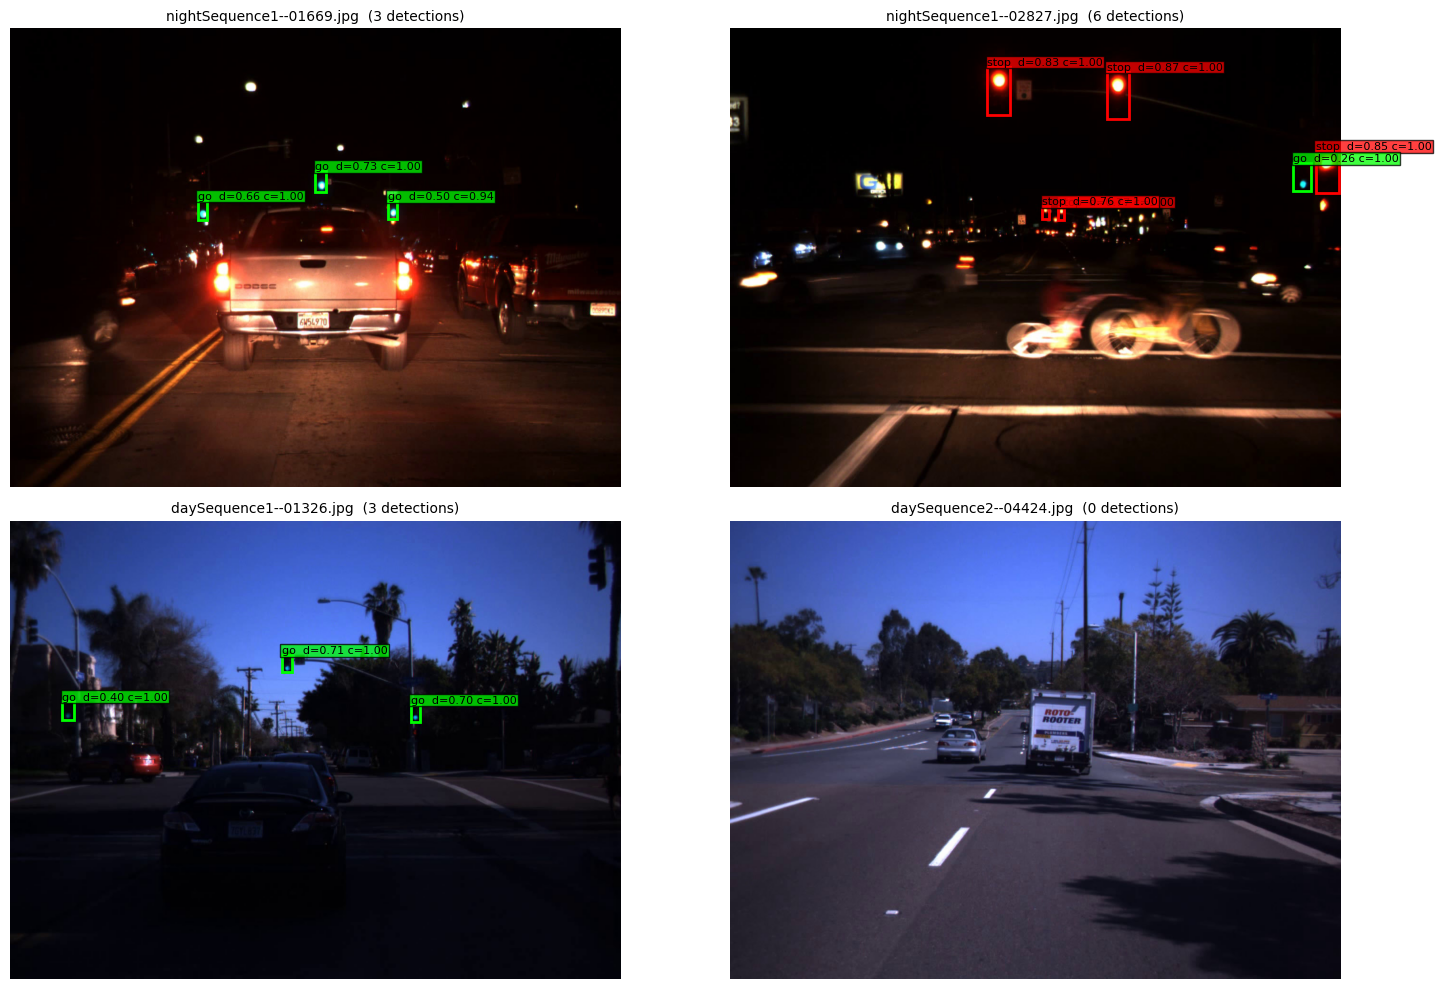


Saved demo: two_stage_demo.png


In [28]:
# 11. TWO-STAGE INFERENCE (sample test images) — wire stage 1 (YOLO) + stage 2 (MobileNetV3) together
import random
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models
from ultralytics import YOLO
from matplotlib.patches import Rectangle

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

stage1_best = sorted(
    RUNS_DIR.glob("stage1_localizer*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)[-1]
print("Stage 1 model:", stage1_best)
stage1 = YOLO(str(stage1_best))

ckpt = torch.load(MODELS_DIR / "stage2_mobilenet.pt", map_location=DEVICE)
S2_CLASSES = ckpt["classes"]
S2_IMG = ckpt["img_size"]
stage2 = models.mobilenet_v3_small(weights=None)
stage2.classifier[3] = nn.Linear(stage2.classifier[3].in_features, len(S2_CLASSES))
stage2.load_state_dict(ckpt["state_dict"])
stage2 = stage2.to(DEVICE).eval()
print("Stage 2 classes:", S2_CLASSES)

s2_tf = transforms.Compose([
    transforms.Resize((S2_IMG, S2_IMG)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def two_stage_predict(image_path, conf=0.25, pad_ratio=0.15):
    """Detect housings with stage 1, classify each crop with stage 2.

    Returns a list of dicts:
        [{box: (x1,y1,x2,y2), state: str, det_conf: float, cls_conf: float}]
    """
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    det = stage1.predict(source=str(image_path), conf=conf, verbose=False)[0]
    out = []
    if det.boxes is None or len(det.boxes) == 0:
        return out
    boxes = det.boxes.xyxy.cpu().numpy()
    confs = det.boxes.conf.cpu().numpy()
    crops, geoms = [], []
    for (x1, y1, x2, y2), c in zip(boxes, confs):
        bw, bh = x2 - x1, y2 - y1
        px, py = bw * pad_ratio, bh * pad_ratio
        cx1 = max(0, int(x1 - px))
        cy1 = max(0, int(y1 - py))
        cx2 = min(W, int(x2 + px))
        cy2 = min(H, int(y2 + py))
        crops.append(s2_tf(img.crop((cx1, cy1, cx2, cy2))))
        geoms.append(((int(x1), int(y1), int(x2), int(y2)), float(c)))
    batch = torch.stack(crops).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(stage2(batch), dim=1)
        cls_conf, cls_idx = probs.max(1)
    for (box, dconf), cidx, ccf in zip(geoms, cls_idx.cpu().numpy(), cls_conf.cpu().numpy()):
        out.append({
            "box": box,
            "state": S2_CLASSES[cidx],
            "det_conf": dconf,
            "cls_conf": float(ccf),
        })
    return out


# ---- Demo on 4 random test images ----
test_imgs = sorted((SRC_IMG / "test").glob("*.jpg"))
random.seed(0)
sample = random.sample(test_imgs, 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, ipath in zip(axes.flat, sample):
    img = Image.open(ipath).convert("RGB")
    preds = two_stage_predict(ipath)
    ax.imshow(img)
    for p in preds:
        x1, y1, x2, y2 = p["box"]
        state = p["state"].lower()
        color = "lime" if "go" in state else ("red" if "stop" in state else "gold")
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                               linewidth=2, edgecolor=color, facecolor='none'))
        label = p["state"].replace("_traffic_light", "").replace("_", " ")
        label += f"  d={p['det_conf']:.2f} c={p['cls_conf']:.2f}"
        ax.text(x1, max(0, y1 - 4), label, color='black', fontsize=8,
                bbox=dict(facecolor=color, alpha=0.75, pad=1))
    ax.set_title(f"{ipath.name}  ({len(preds)} detections)", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "two_stage_demo.png", dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved demo: two_stage_demo.png")


## Step 12: Evaluate the Pipeline

Three views of model quality on the **test split** (held-out images):

1. **Stage 1 — Detection metrics** (Ultralytics `val()`): precision, recall, mAP50, mAP50-95 on housings.
2. **Stage 2 — Classification metrics**: confusion matrix + per-class precision/recall/F1 on the held-out crops.
3. **End-to-end pipeline accuracy**: feed each test image through the full pipeline, match
   each detection to ground-truth boxes by IoU, and check whether the predicted state matches.

<!-- STEP-12-EVAL -->


In [29]:
# 12a. STAGE 1 — Detection metrics on test split
# STEP-12-EVAL
# Uses ultralytics' built-in val() loop. Computes precision, recall, mAP50, mAP50-95
# for the single class 'traffic_light' on data/stage1/images/test.
from ultralytics import YOLO

stage1_best = sorted(
    RUNS_DIR.glob("stage1_localizer*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)[-1]
print("Evaluating Stage 1:", stage1_best)

stage1_eval = YOLO(str(stage1_best))
metrics = stage1_eval.val(
    data=str(STAGE1_DIR / 'data.yaml'),
    split='test',
    imgsz=1280,
    device=0,
    verbose=True,
)
print()
print("Stage 1 test metrics:")
print(f"  precision   = {metrics.box.mp:.4f}")
print(f"  recall      = {metrics.box.mr:.4f}")
print(f"  mAP@0.5     = {metrics.box.map50:.4f}")
print(f"  mAP@0.5:.95 = {metrics.box.map:.4f}")


Evaluating Stage 1: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/runs/stage1_localizer-5/weights/best.pt
Ultralytics 8.4.45 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5090, 32101MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2902.4±1548.8 MB/s, size: 86.2 KB)
val: Scanning /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/stage1/labels/test... 22481 images, 4229 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 22481/22481 4.6Kit/s 4.9s0.0s
val: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/stage1/images/test/daySequence1--03027.jpg: 1 duplicate labels removed
val: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/stage1/images/test/daySequence1--03028.jpg: 1 duplicate labels removed
val: /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/data/stage1/images/test/daySequence1--03029.jpg: 1 duplicate labels removed
val

In [34]:
# 12b. STAGE 2 — Classification metrics on test crops
# STEP-12-EVAL
# Confusion matrix + per-class precision/recall/F1 on data/stage2/test/.
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

try:
    from sklearn.metrics import confusion_matrix, classification_report
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False
    print("(install scikit-learn for a nicer classification report: `pip install scikit-learn`)")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ckpt = torch.load(MODELS_DIR / "stage2_mobilenet.pt", map_location=DEVICE)
S2_CLASSES = ckpt["classes"]
S2_IMG = ckpt["img_size"]

eval_tf = transforms.Compose([
    transforms.Resize((S2_IMG, S2_IMG)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
test_ds = datasets.ImageFolder(STAGE2_DIR / "test", transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

net = models.mobilenet_v3_small(weights=None)
net.classifier[3] = nn.Linear(net.classifier[3].in_features, len(S2_CLASSES))
net.load_state_dict(ckpt["state_dict"])
net = net.to(DEVICE).eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        pred = net(x.to(DEVICE)).argmax(1).cpu().numpy()
        y_true.extend(y.numpy().tolist())
        y_pred.extend(pred.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
acc = (y_true == y_pred).mean()
print(f"Stage 2 test accuracy: {acc*100:.2f}%   (n={len(y_true)})")

if SKLEARN_OK:
    print()
    print(classification_report(y_true, y_pred, target_names=S2_CLASSES, digits=3))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(S2_CLASSES))))
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(S2_CLASSES)))
    ax.set_yticks(range(len(S2_CLASSES)))
    ax.set_xticklabels([c.replace('_traffic_light','') for c in S2_CLASSES], rotation=45, ha='right')
    ax.set_yticklabels([c.replace('_traffic_light','') for c in S2_CLASSES])
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_title(f'Stage 2 confusion matrix (test, acc={acc*100:.1f}%)')
    # write counts on cells
    for i in range(len(S2_CLASSES)):
        for j in range(len(S2_CLASSES)):
            v = cm[i, j]
            ax.text(j, i, str(v), ha='center', va='center',
                    color='white' if v > cm.max() * 0.5 else 'black', fontsize=8)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "stage2_confusion_matrix.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: stage2_confusion_matrix.png")


(install scikit-learn for a nicer classification report: `pip install scikit-learn`)
Stage 2 test accuracy: 92.05%   (n=30339)


In [33]:
# 12c. END-TO-END — pipeline accuracy on the test split
# STEP-12-EVAL
# For every test image:
#   1) run two_stage_predict() to get [(box, state), ...]
#   2) load the ground-truth boxes + (housing) class names from data/processed/labels/test
#   3) match predicted boxes to GT boxes by IoU >= 0.5
#   4) a prediction is a TRUE POSITIVE only if its state also matches the GT class
# Reports box-level precision/recall (TP/FP/FN) and state-level accuracy on matched pairs.
import yaml
import numpy as np
from PIL import Image

with open(DATA_PROCESSED_DIR / "data.yaml") as f:
    _gt_yaml = yaml.safe_load(f)
GT_CLASSES = [_gt_yaml["names"][i] for i in range(_gt_yaml["nc"])]
# Stage 2 stores class names with underscores; processed data.yaml uses spaces.
GT_TO_S2 = {c: c.replace(" ", "_") for c in GT_CLASSES}

def _iou(a, b):
    xa1, ya1, xa2, ya2 = a
    xb1, yb1, xb2, yb2 = b
    ix1, iy1 = max(xa1, xb1), max(ya1, yb1)
    ix2, iy2 = min(xa2, xb2), min(ya2, yb2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter <= 0:
        return 0.0
    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    return inter / (area_a + area_b - inter + 1e-9)

IOU_THR = 0.5
test_imgs = sorted((SRC_IMG / "test").glob("*.jpg"))
print(f"Evaluating on {len(test_imgs)} test images (IoU threshold = {IOU_THR}) ...")

tp = fp = fn = 0
state_correct = state_total = 0
for img_path in test_imgs:
    # Labels are named "<image_name>.txt" (e.g. "daySequence1--00000.jpg.txt")
    lbl_path = SRC_LBL / "test" / (img_path.name + ".txt")
    if not lbl_path.exists():
        continue
    img = Image.open(img_path)
    W, H = img.size
    # ground truth (xyxy in pixels) + class name (S2 form)
    gts = []
    for line in lbl_path.read_text().splitlines():
        if not line.strip():
            continue
        cid, cx, cy, bw, bh = line.split()
        cid = int(cid); cx, cy, bw, bh = map(float, (cx, cy, bw, bh))
        x1 = (cx - bw/2)*W; y1 = (cy - bh/2)*H
        x2 = (cx + bw/2)*W; y2 = (cy + bh/2)*H
        gts.append({"box": (x1, y1, x2, y2), "state": GT_TO_S2[GT_CLASSES[cid]], "matched": False})

    preds = two_stage_predict(img_path)
    # match each pred to the best unmatched GT by IoU
    for p in preds:
        best_iou, best_j = 0.0, -1
        for j, g in enumerate(gts):
            if g["matched"]:
                continue
            iou = _iou(p["box"], g["box"])
            if iou > best_iou:
                best_iou, best_j = iou, j
        if best_iou >= IOU_THR and best_j >= 0:
            gts[best_j]["matched"] = True
            tp += 1
            state_total += 1
            if p["state"] == gts[best_j]["state"]:
                state_correct += 1
        else:
            fp += 1
    fn += sum(1 for g in gts if not g["matched"])

prec = tp / (tp + fp + 1e-9)
rec  = tp / (tp + fn + 1e-9)
f1   = 2 * prec * rec / (prec + rec + 1e-9)
state_acc = state_correct / max(1, state_total)

print(f"\nDetection (housing localization at IoU>={IOU_THR}):")
print(f"  TP={tp}  FP={fp}  FN={fn}")
print(f"  precision = {prec*100:.2f}%")
print(f"  recall    = {rec*100:.2f}%")
print(f"  F1        = {f1*100:.2f}%")
print(f"\nState classification on TP detections:")
print(f"  correct = {state_correct} / {state_total}   ({state_acc*100:.2f}%)")
print(f"\nEND-TO-END (correct box AND correct state):")
print(f"  joint = {state_correct} / ({state_correct + fp + fn})  = "
      f"{state_correct / max(1, state_correct + fp + fn) * 100:.2f}%")


Evaluating on 22481 test images (IoU threshold = 0.5) ...

Detection (housing localization at IoU>=0.5):
  TP=30571  FP=8993  FN=27131
  precision = 77.27%
  recall    = 52.98%
  F1        = 62.86%

State classification on TP detections:
  correct = 29314 / 30571   (95.89%)

END-TO-END (correct box AND correct state):
  joint = 29314 / (65438)  = 44.80%


## Step 13: Run the Pipeline on a Video

Streams a video file through the two-stage pipeline frame by frame and writes
an annotated `.mp4` with colored boxes per detected light (green = go,
red = stop, gold = warning).

**Requires:** cell 27 (Step 11) must have been run in this kernel — it loads
the Stage 1 / Stage 2 models and defines `two_stage_predict`. If you restarted
the kernel, re-run cell 27 first.


In [36]:
# 13. VIDEO INFERENCE — two-stage pipeline on a video file
import time
import cv2
import numpy as np
import torch
from PIL import Image

assert "stage1" in globals() and "stage2" in globals() and "s2_tf" in globals(), \
    "Run cell 27 (Step 11) first to load the models."

# --- inputs / outputs --------------------------------------------------------
VIDEO_IN  = PROJECT_ROOT / "test_videos" / "Traffic-light.mp4"   # change to test a different clip
VIDEO_OUT = PROJECT_ROOT / "runs" / "two_stage_video" / f"{VIDEO_IN.stem}_annotated.mp4"
VIDEO_OUT.parent.mkdir(parents=True, exist_ok=True)

CONF_THR     = 0.25     # Stage 1 detection threshold
PAD_RATIO    = 0.15     # crop padding around each housing for Stage 2
FRAME_STRIDE = 1        # set to 2 or 3 to skip frames for faster output

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- helper: predict on a PIL image (no file I/O per frame) -----------------
def _predict_pil(pil_img, conf=CONF_THR, pad_ratio=PAD_RATIO):
    W, H = pil_img.size
    det = stage1.predict(source=np.array(pil_img), conf=conf, verbose=False)[0]
    out = []
    if det.boxes is None or len(det.boxes) == 0:
        return out
    boxes = det.boxes.xyxy.cpu().numpy()
    confs = det.boxes.conf.cpu().numpy()
    crops, geoms = [], []
    for (x1, y1, x2, y2), c in zip(boxes, confs):
        bw, bh = x2 - x1, y2 - y1
        px, py = bw * pad_ratio, bh * pad_ratio
        cx1 = max(0, int(x1 - px)); cy1 = max(0, int(y1 - py))
        cx2 = min(W, int(x2 + px)); cy2 = min(H, int(y2 + py))
        crops.append(s2_tf(pil_img.crop((cx1, cy1, cx2, cy2))))
        geoms.append(((int(x1), int(y1), int(x2), int(y2)), float(c)))
    batch = torch.stack(crops).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(stage2(batch), dim=1)
        cls_conf, cls_idx = probs.max(1)
    for (box, dconf), cidx, ccf in zip(geoms, cls_idx.cpu().numpy(), cls_conf.cpu().numpy()):
        out.append({
            "box": box, "state": S2_CLASSES[cidx],
            "det_conf": dconf, "cls_conf": float(ccf),
        })
    return out

def _color_for(state):
    s = state.lower()
    if "go" in s:   return (0, 255, 0)    # green (BGR)
    if "stop" in s: return (0, 0, 255)    # red
    return (0, 200, 255)                  # gold-ish (warning)

# --- open video, write annotated copy ---------------------------------------
cap = cv2.VideoCapture(str(VIDEO_IN))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_IN}")
fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Input  : {VIDEO_IN}")
print(f"Size   : {W}x{H} @ {fps:.1f} fps, {total} frames")
print(f"Output : {VIDEO_OUT}")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(VIDEO_OUT), fourcc, fps / FRAME_STRIDE, (W, H))

frame_idx = 0
written   = 0
total_det = 0
t0 = time.time()
try:
    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break
        if frame_idx % FRAME_STRIDE == 0:
            pil = Image.fromarray(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
            preds = _predict_pil(pil)
            total_det += len(preds)
            for p in preds:
                x1, y1, x2, y2 = p["box"]
                clr = _color_for(p["state"])
                cv2.rectangle(frame_bgr, (x1, y1), (x2, y2), clr, 2)
                label = p["state"].replace("_traffic_light", "").replace("_", " ")
                label += f" {p['cls_conf']:.2f}"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
                cv2.rectangle(frame_bgr, (x1, max(0, y1 - th - 4)),
                              (x1 + tw + 4, y1), clr, -1)
                cv2.putText(frame_bgr, label, (x1 + 2, max(th, y1) - 2),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
            writer.write(frame_bgr)
            written += 1
            if written % 50 == 0:
                elapsed = time.time() - t0
                print(f"  frame {frame_idx}/{total}  written {written}  "
                      f"detections so far {total_det}  ({written/elapsed:.1f} fps)")
        frame_idx += 1
finally:
    cap.release()
    writer.release()

elapsed = time.time() - t0
print(f"\nDone. Wrote {written} frames in {elapsed:.1f}s "
      f"({written/elapsed:.1f} output fps). Detections total: {total_det}")
print(f"Annotated video: {VIDEO_OUT}")


Input  : /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/test_videos/Traffic-light.mp4
Size   : 1280x720 @ 30.0 fps, 1823 frames
Output : /home/auto_drive/Desktop/Traffic_Light_DetectioniCV project/runs/two_stage_video/Traffic-light_annotated.mp4
  frame 49/1823  written 50  detections so far 15  (79.3 fps)
  frame 99/1823  written 100  detections so far 36  (79.6 fps)
  frame 149/1823  written 150  detections so far 36  (84.1 fps)
  frame 199/1823  written 200  detections so far 36  (85.8 fps)
  frame 249/1823  written 250  detections so far 36  (87.1 fps)
  frame 299/1823  written 300  detections so far 41  (86.6 fps)
  frame 349/1823  written 350  detections so far 44  (87.3 fps)
  frame 399/1823  written 400  detections so far 44  (87.6 fps)
  frame 449/1823  written 450  detections so far 44  (88.1 fps)
  frame 499/1823  written 500  detections so far 47  (88.5 fps)
  frame 549/1823  written 550  detections so far 47  (89.0 fps)
  frame 599/1823  written 600  detection

## Summary

What this notebook does, end to end:

1. **Steps 1–6** — Read the LISA dataset, examine annotation format, visualize a frame,
   convert to YOLO format, split off 10% for validation, and write `data/processed/data.yaml`.
2. **Step 7** — Drop the 7 bulb classes (~3 px at imgsz=640 → below YOLO's detection floor)
   and renumber the remaining 7 housing classes 0–6.
3. **Step 8** — Sanity-check the prepared labels.
4. **Step 9** — Install `ultralytics`.
5. **Step 10 — Train the two-stage pipeline**
   - 10a: build `data/stage1/` (1-class housing labels)
   - 10b: train Stage 1 (YOLOv8n, 1 class, imgsz=1280)
   - 10c: build `data/stage2/` (housing crops)
   - 10d: train Stage 2 (MobileNetV3-Small, 7-class state classifier)
6. **Step 11** — Visual test on random test images (`two_stage_demo.png`).
7. **Step 12** — Quantitative evaluation: Stage 1 detection metrics,
   Stage 2 confusion matrix, and end-to-end pipeline accuracy.

Outputs live in:
- `runs/stage1_localizer/weights/best.pt`
- `models/stage2_mobilenet.pt`
- `two_stage_demo.png`, `stage2_confusion_matrix.png`
